In [1]:
import pandas as pd
import random

In [2]:
L = []
for i in range(10000):
  a = random.randint(1,6)
  b = random.randint(1,6)

  L.append(a + b)

In [3]:
len(L)

10000

In [4]:
L[:5]

[2, 8, 10, 4, 5]

In [5]:
s = (pd.Series(L).value_counts()/pd.Series(L).value_counts().sum()).sort_index()

In [6]:
import numpy as np
np.cumsum(s)

2     0.0302
3     0.0853
4     0.1711
5     0.2850
6     0.4260
7     0.5878
8     0.7245
9     0.8341
10    0.9179
11    0.9718
12    1.0000
Name: count, dtype: float64

<Axes: >

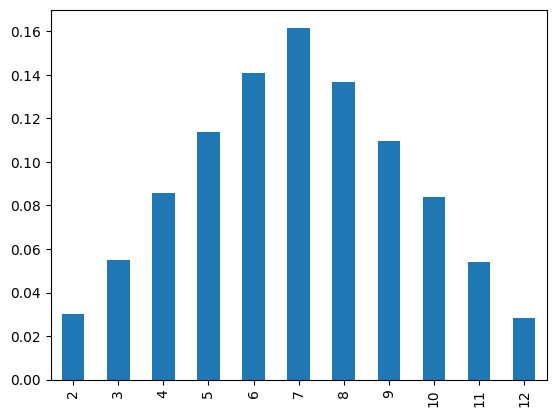

In [7]:
s.plot(kind='bar')

<Axes: >

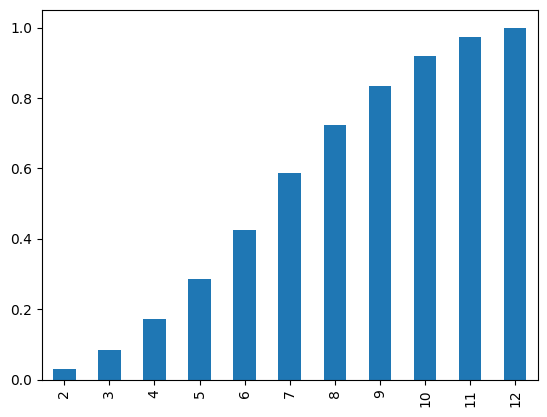

In [9]:
np.cumsum(s).plot(kind='bar')

# parametric density finction

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import normal

sample = normal(loc=50, scale=5,size=1000)

In [11]:
sample.mean()

np.float64(49.873585231875104)

(array([  4.,  21.,  56., 128., 195., 234., 191., 110.,  46.,  15.]),
 array([33.5422243 , 36.57340432, 39.60458435, 42.63576437, 45.66694439,
        48.69812441, 51.72930444, 54.76048446, 57.79166448, 60.8228445 ,
        63.85402453]),
 <BarContainer object of 10 artists>)

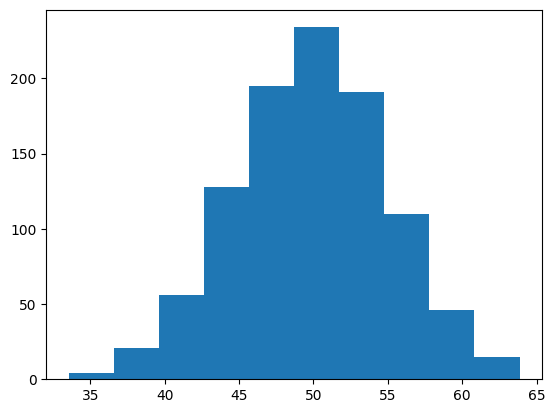

In [14]:
# plot histogram to understand the distribution of data
plt.hist(sample,bins=10)

In [15]:
# calculate sample mean and sample std dev
sample_mean = sample.mean()
sample_std = sample.std()

In [16]:
# fit the distribution with the above parameters

from scipy.stats import norm
dist = norm(60, 12)

In [17]:
values = np.linspace(sample.min(),sample.max(),100)

In [18]:
sample.max()

np.float64(63.854024525227935)

In [19]:
probabilities = [dist.pdf(value) for value in values]

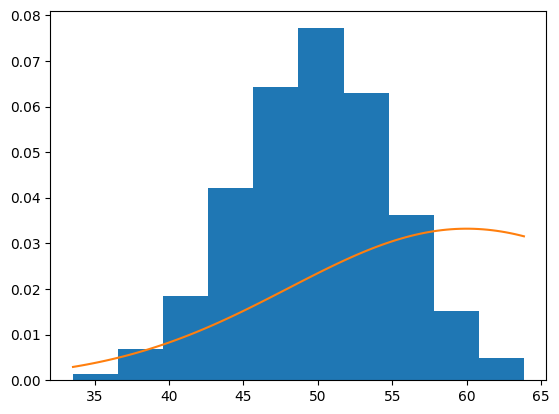

In [20]:
# plot the histogram and pdf
plt.hist(sample,bins=10,density=True)
plt.plot(values,probabilities)

C:\Users\niles\AppData\Local\Temp\ipykernel_13308\1482356190.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

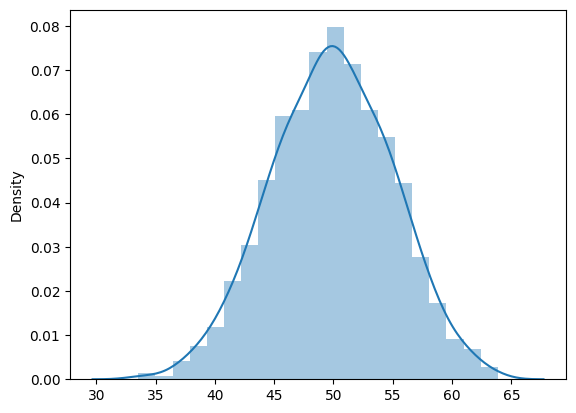

In [21]:
import seaborn as sns
sns.distplot(sample)

# KDE

In [22]:
# generate a sample
sample1 = normal(loc=20, scale=5, size=300)
sample2 = normal(loc=40, scale=5, size=700)
sample = np.hstack((sample1, sample2))

In [23]:
sample

array([14.42607215, 13.72129822, 18.515805  , 18.28041351, 18.98008366,
       17.75029713, 25.20191426, 16.93963822, 22.36205731, 22.00185552,
       21.21910727, 25.22285419, 30.11158164, 18.66090221, 17.66122521,
       27.25479179, 16.18773985, 28.63801792, 15.6479324 , 10.70356057,
       24.4267314 , 17.14508307, 27.36851865, 21.85739129, 23.69935719,
       21.15978541, 24.49985763, 23.22796908, 15.1467507 , 11.84982231,
       16.26835752, 22.18744029, 15.68909455, 14.92060419, 18.58979844,
        6.82406077, 18.60744143, 29.82024594, 19.78800599, 15.20516433,
       11.89367432, 20.47774443, 21.81590244, 24.19263924, 19.65690852,
       13.70956673, 16.62310376, 17.41195581, 30.31303555, 13.35579904,
       23.04503338, 18.72049855, 15.11728162, 27.29200703, 26.86227141,
       23.1019464 , 17.35864675, 23.15921392, 12.42285552, 18.86263272,
       21.96342743, 24.0084776 ,  6.40053424, 13.42957743, 16.06474592,
       20.54566331, 20.01808317, 21.80345672, 25.16225931, 19.73

(array([ 3.,  0.,  1.,  1.,  4.,  6., 11., 12., 14., 12., 22., 15., 24.,
        17., 21., 32., 14., 22., 15., 16., 14., 12., 10., 12., 20., 15.,
        17., 18., 32., 38., 25., 51., 57., 57., 66., 43., 56., 39., 51.,
        35., 24., 17.,  5.,  8.,  4.,  4.,  2.,  3.,  1.,  2.]),
 array([ 6.00143674,  7.00205814,  8.00267954,  9.00330093, 10.00392233,
        11.00454372, 12.00516512, 13.00578652, 14.00640791, 15.00702931,
        16.00765071, 17.0082721 , 18.0088935 , 19.00951489, 20.01013629,
        21.01075769, 22.01137908, 23.01200048, 24.01262187, 25.01324327,
        26.01386467, 27.01448606, 28.01510746, 29.01572885, 30.01635025,
        31.01697165, 32.01759304, 33.01821444, 34.01883583, 35.01945723,
        36.02007863, 37.02070002, 38.02132142, 39.02194281, 40.02256421,
        41.02318561, 42.023807  , 43.0244284 , 44.0250498 , 45.02567119,
        46.02629259, 47.02691398, 48.02753538, 49.02815678, 50.02877817,
        51.02939957, 52.03002096, 53.03064236, 54.03126376,

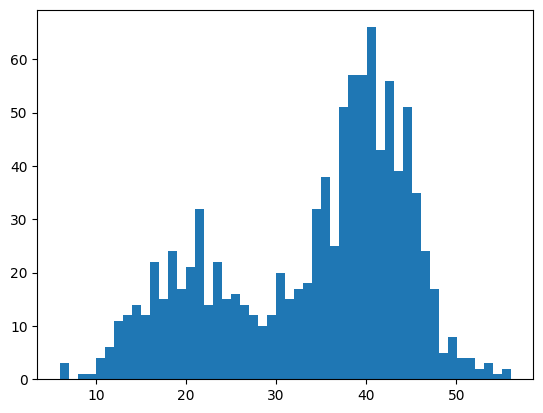

In [24]:
# plot histogram bins=50
plt.hist(sample,bins=50)

In [25]:
from sklearn.neighbors import KernelDensity

model = KernelDensity(bandwidth=5, kernel='gaussian')

# convert data to a 2D array
sample = sample.reshape((len(sample), 1))

model.fit(sample)

,"bandwidth bandwidth: float or {""scott"", ""silverman""}, default=1.0The bandwidth of the kernel. If bandwidth is a float, it defines thebandwidth of the kernel. If bandwidth is a string, one of the estimationmethods is implemented.",5
,"algorithm algorithm: {'kd_tree', 'ball_tree', 'auto'}, default='auto'The tree algorithm to use.",'auto'
,"kernel kernel: {'gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear', 'cosine'}, default='gaussian'The kernel to use.",'gaussian'
,"metric metric: str, default='euclidean'Metric to use for distance computation. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.Not all metrics are valid with all algorithms: refer to thedocumentation of :class:`BallTree` and :class:`KDTree`. Note that thenormalization of the density output is correct only for the Euclideandistance metric.",'euclidean'
,"atol atol: float, default=0The desired absolute tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"rtol rtol: float, default=0The desired relative tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"breadth_first breadth_first: bool, default=TrueIf true (default), use a breadth-first approach to the problem.Otherwise use a depth-first approach.",True
,"leaf_size leaf_size: int, default=40Specify the leaf size of the underlying tree. See :class:`BallTree`or :class:`KDTree` for details.",40
,"metric_params metric_params: dict, default=NoneAdditional parameters to be passed to the tree for use with themetric. For more information, see the documentation of:class:`BallTree` or :class:`KDTree`.",None


In [26]:
values = np.linspace(sample.min(),sample.max(),100)
values = values.reshape((len(values), 1))

In [27]:
probabilities = model.score_samples(values)
probabilities = np.exp(probabilities)

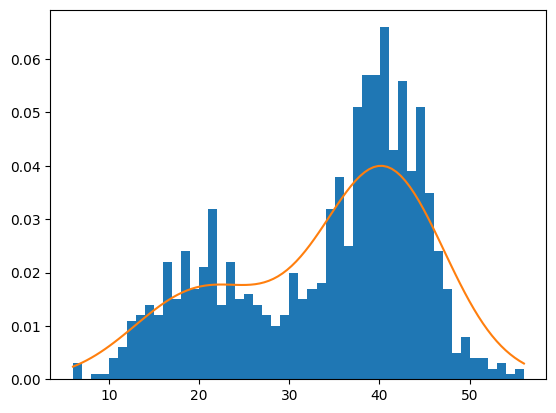

In [28]:
plt.hist(sample, bins=50, density=True)
plt.plot(values[:], probabilities)
plt.show()

<Axes: ylabel='Density'>

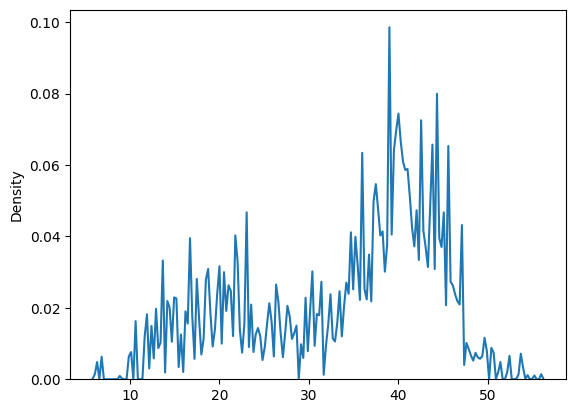

In [29]:
sns.kdeplot(sample.reshape(1000),bw_adjust=0.02)

In [30]:
import seaborn as sns
df = sns.load_dataset('iris')

In [32]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Density'>

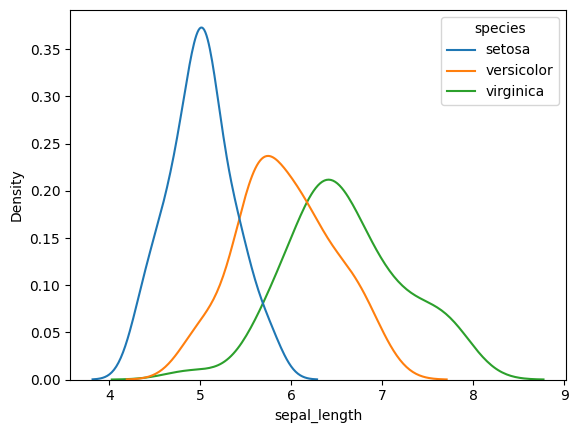

In [33]:
sns.kdeplot(data=df,x='sepal_length',hue='species')

<Axes: xlabel='sepal_width', ylabel='Density'>

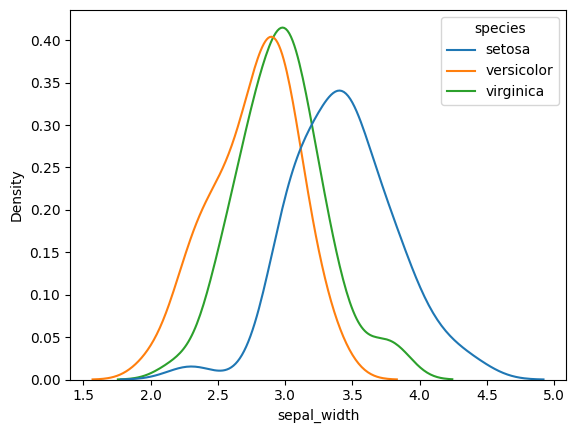

In [34]:
sns.kdeplot(data=df,x='sepal_width',hue='species')

<Axes: xlabel='petal_length', ylabel='Density'>

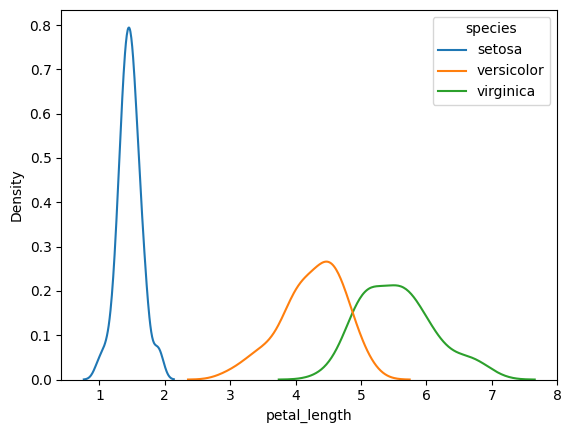

In [35]:
sns.kdeplot(data=df,x='petal_length',hue='species')

<Axes: xlabel='petal_width', ylabel='Density'>

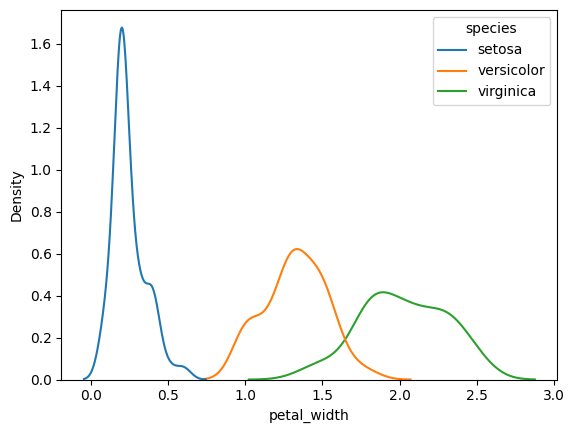

In [36]:
sns.kdeplot(data=df,x='petal_width',hue='species')

In [38]:
sns.kdeplot(df['petal_width'], hue=df['species'])
sns.ecdfplot(data=df, x='petal_width', hue='species')


ValueError: The following variable cannot be assigned with wide-form data: `hue`